### Overpaying the loan balance

In [12]:
from quant_slc_hedging.data_model import LoanModelInputs, SalaryModelInputs, SalaryGrowthType, salary_growth_amounts, InvestmentModelInputs
from quant_slc_hedging.salary import SalaryModel
from quant_slc_hedging.loan import LoanModel
from quant_slc_hedging.strategies.base_strategy import Strategy
from quant_slc_hedging.strategies.min_repayment import MinRepaymentStrategy
from quant_slc_hedging.simulation import SimulationHandler, SimulationResult
from quant_slc_hedging.strategies.fixed_pct_repayment import FixedPctRepaymentStrategy
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [15]:
n_paths = 10_000
years_remaining = 30
observations = 12 * 30
seed = 1234
starting_salary = 35_000
initial_loan = 45_000
initial_investment_balance = 0
salary_growth = SalaryGrowthType(growth_type="Medium")

In [18]:
salary_config=SalaryModelInputs(
    starting_salary=starting_salary,
    salary_growth_dist=salary_growth
    )
loan_config = LoanModelInputs(
    initial_loan_balance=initial_loan,
    remaining_loan_term_months=12*years_remaining
)
investment_config = InvestmentModelInputs(
    initial_investment_balance=initial_investment_balance,
    annual_expected_return=0.07,
    annual_vol=0.20,
    annual_risk_free_rate=0.05,
    payoff_loan_with_investments=False
)
salary_rng = np.random.default_rng(seed)
investment_rng = np.random.default_rng(seed + 1) 
strategy_mr = MinRepaymentStrategy()
sim_mr = SimulationHandler(salary_config=salary_config, loan_config=loan_config, investment_config=investment_config, strategy=strategy_mr, n_paths=n_paths, observations=observations, salary_rng=salary_rng)
res_min_repaymenty = sim_mr.run_simulation()

strategy_ap = FixedPctRepaymentStrategy(fixed_excess_pct=0.05, repayment_threshold=loan_config.repayment_threshold)
sim_ap = SimulationHandler(salary_config=salary_config, loan_config=loan_config, investment_config=investment_config, strategy=strategy_ap, n_paths=n_paths, observations=observations, salary_rng=salary_rng)
res_add_repayment = sim_ap.run_simulation()

Sim finished
Sim finished


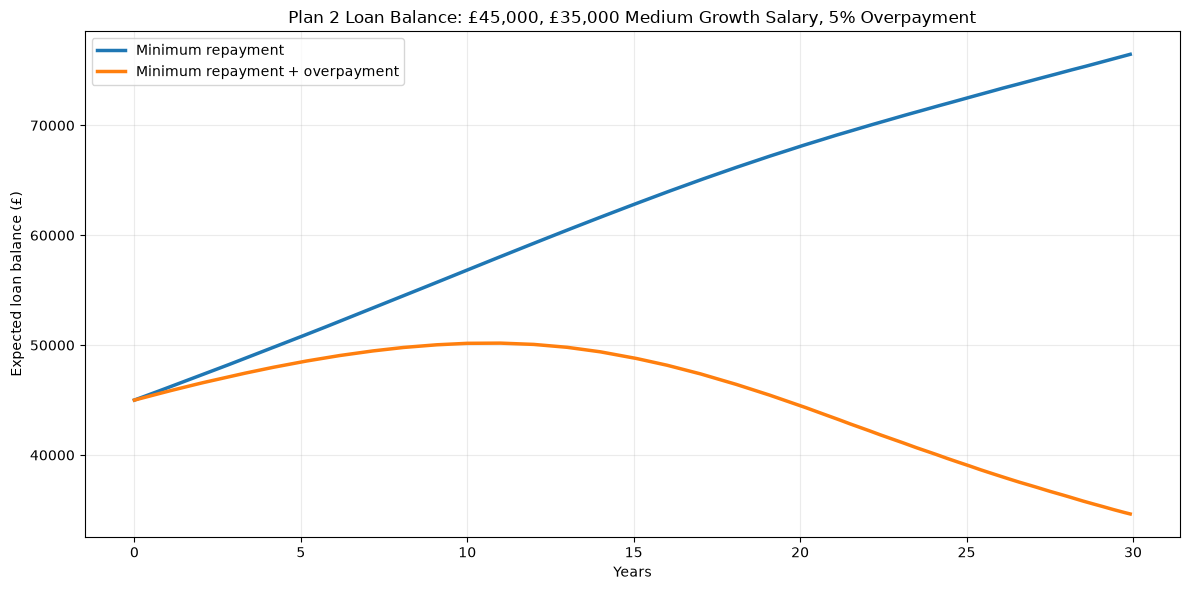

In [22]:
# Mean loan balance across Monte Carlo paths
mean_min = res_min_repaymenty.loan_result.loan_balance.mean(axis=0)
mean_overpay = res_add_repayment.loan_result.loan_balance.mean(axis=0)

months = np.arange(len(mean_min))
years = months / 12

plt.figure(figsize=(12, 6))

plt.plot(
    years,
    mean_min,
    linewidth=2.5,
    label="Minimum repayment"
)

plt.plot(
    years,
    mean_overpay,
    linewidth=2.5,
    label="Minimum repayment + overpayment"
)

plt.xlabel("Years")
plt.ylabel("Expected loan balance (£)")
plt.title("Plan 2 Loan Balance: £45,000, £35,000 Medium Growth Salary, 5% Overpayment")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

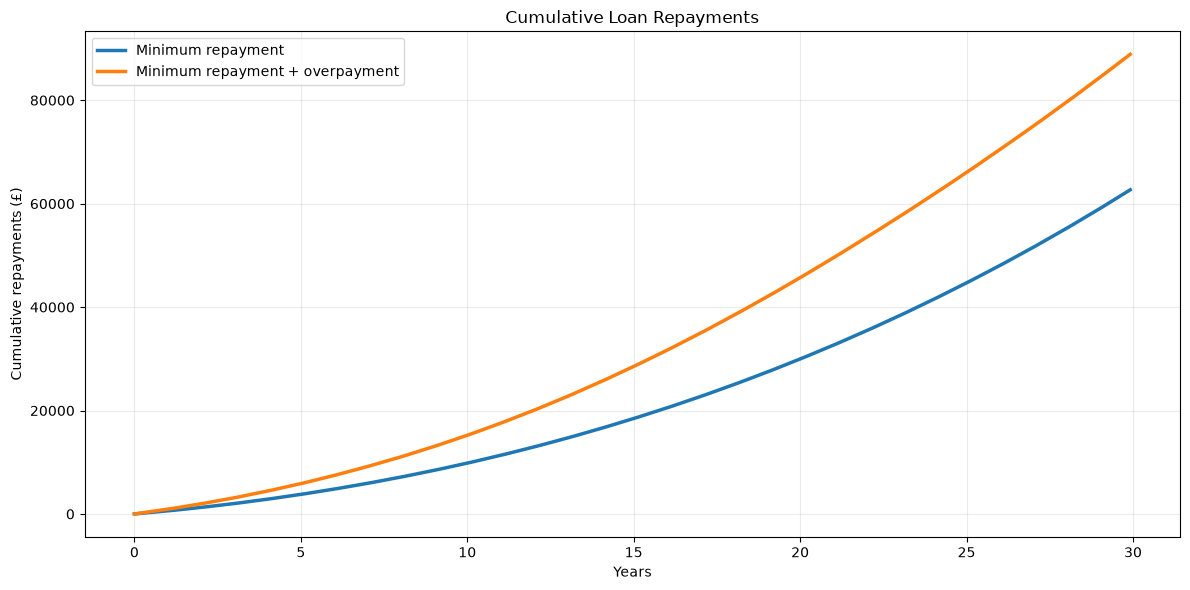

In [23]:
mean_min_repayment = (
    res_min_repaymenty.loan_result.base_repayment.mean(axis=0)
    .cumsum()
)

mean_min_overpay = (
    res_add_repayment.loan_result.base_repayment.mean(axis=0)
    .cumsum()
    +
    res_add_repayment.loan_result.additional_repayment.mean(axis=0)
    .cumsum()
)

plt.figure(figsize=(12, 6))

plt.plot(
    years,
    mean_min_repayment,
    linewidth=2.5,
    label="Minimum repayment"
)

plt.plot(
    years,
    mean_min_overpay,
    linewidth=2.5,
    label="Minimum repayment + overpayment"
)

plt.xlabel("Years")
plt.ylabel("Cumulative repayments (£)")
plt.title("Cumulative Loan Repayments")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

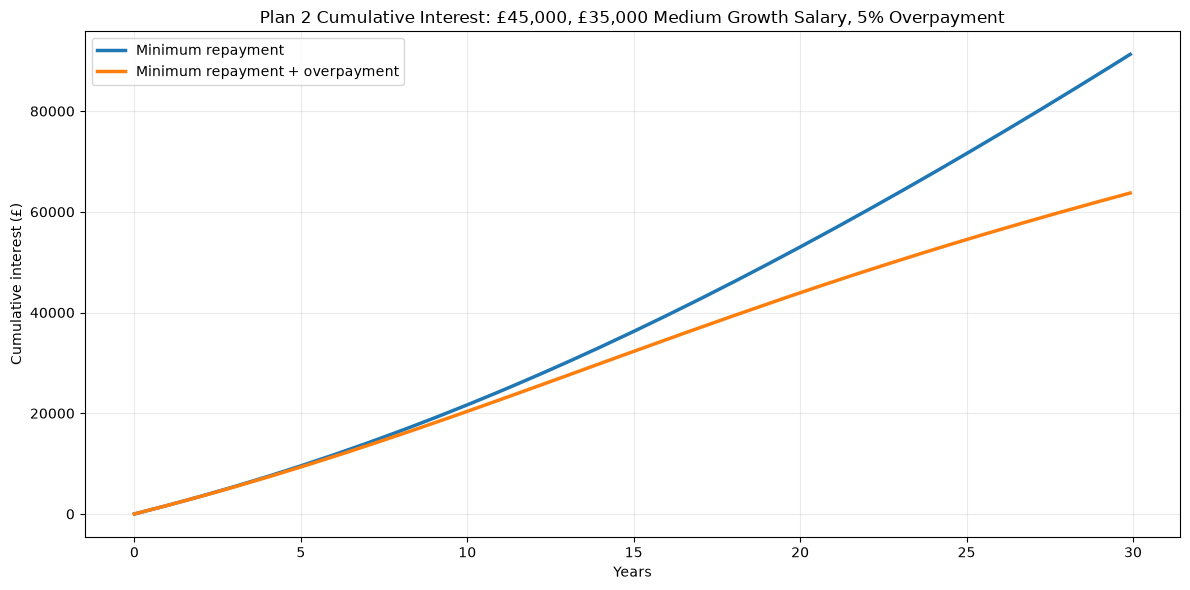

In [25]:
mean_interest_min = (
    res_min_repaymenty.loan_result.interest_accrued.mean(axis=0)
    .cumsum()
)

mean_interest_overpay = (
    res_add_repayment.loan_result.interest_accrued.mean(axis=0)
    .cumsum()
)

plt.figure(figsize=(12, 6))

plt.plot(
    years,
    mean_interest_min,
    linewidth=2.5,
    label="Minimum repayment"
)

plt.plot(
    years,
    mean_interest_overpay,
    linewidth=2.5,
    label="Minimum repayment + overpayment"
)

plt.xlabel("Years")
plt.ylabel("Cumulative interest (£)")
plt.title("Plan 2 Cumulative Interest: £45,000, £35,000 Medium Growth Salary, 5% Overpayment")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
additional_interest = res_min_repaymenty.loan_result.interest_accrued.mean(axis=0).cumsum()[-1] / res_add_repayment.loan_result.interest_accrued.mean(axis=0).cumsum()[-1] - 1
print(f"Min repayment generates additional interest of {additional_interest * 100}%")

Min repayment generates additional interest of 43.20757979651757%


In [32]:
res_min_repaymenty.loan_result.interest_accrued.mean(axis=0).cumsum()[-1] 

np.float64(91282.63505727684)